# Módulo 3 — Previsão de No-Show em Consultas (ClínicaCare)

**Desafio Final — Workshop de Dados 2026.2**
**Tema 1:** Previsão de No-Show

Este notebook cobre todo o pipeline exigido para o Módulo 3: extração dos dados do
banco `clinica_care` (MySQL), engenharia de atributos (*features*), tratamento de
dados, análise estatística com NumPy, visualizações com Matplotlib e um modelo de
classificação (Regressão Logística) para prever se um paciente vai faltar à
consulta agendada, com avaliação e interpretação dos resultados.

**Bibliotecas:** pandas, numpy, matplotlib, scikit-learn, pymysql.


## 1. Extração dos dados

Os dados são extraídos diretamente do banco `clinica_care` (criado no Módulo 2),
unindo a tabela `consultas` com `especialidades`, `pacientes` e `convenios` para
trazer, em uma única tabela, tudo o que pode ser relevante para prever o no-show.


In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

engine = create_engine("mysql+pymysql://root:@127.0.0.1/clinica_care")

query = '''
SELECT
    co.id_consulta,
    co.id_paciente,
    co.id_medico,
    co.id_especialidade,
    e.nome_especialidade,
    co.data_consulta,
    co.hora_consulta,
    co.data_agendamento,
    co.status,
    co.valor,
    p.data_nascimento,
    p.genero,
    conv.tipo AS tipo_convenio
FROM consultas co
JOIN especialidades e ON e.id_especialidade = co.id_especialidade
JOIN pacientes p ON p.id_paciente = co.id_paciente
JOIN convenios conv ON conv.id_convenio = p.id_convenio
ORDER BY co.id_paciente, co.data_consulta, co.hora_consulta;
'''

df_raw = pd.read_sql(query, engine, parse_dates=["data_consulta", "data_agendamento", "data_nascimento"])
print("Linhas extraídas do banco:", len(df_raw))
df_raw["status"].value_counts()

Linhas extraídas do banco: 165


status
Realizada    104
Faltou        27
Cancelada     22
Agendada      12
Name: count, dtype: int64

In [2]:
df_raw.head()

,id_consulta,id_paciente,id_medico,id_especialidade,nome_especialidade,data_consulta,hora_consulta,data_agendamento,status,valor,data_nascimento,genero,tipo_convenio
0,41,1,4,7,Psiquiatria,2025-11-27,0 days 14:30:00,2025-11-11 10:00:00,Realizada,285.39,1998-09-21,Masculino,Particular
1,12,1,11,6,Ortopedia,2026-01-22,0 days 14:00:00,2025-12-17 08:00:00,Realizada,212.36,1998-09-21,Masculino,Particular
2,20,1,13,14,Reumatologia,2026-04-24,0 days 15:30:00,2026-03-13 09:00:00,Realizada,300.53,1998-09-21,Masculino,Particular
3,55,1,9,9,Endocrinologia,2026-05-13,0 days 16:00:00,2026-04-13 13:00:00,Faltou,254.26,1998-09-21,Masculino,Particular
4,133,1,9,9,Endocrinologia,2026-05-29,0 days 17:00:00,2026-04-28 18:00:00,Faltou,296.65,1998-09-21,Masculino,Particular


## 2. Tratamento de dados

Verificação de valores nulos e tratamento básico antes de seguir para a engenharia
de atributos. Não há nulos relevantes nesta base (dados gerados de forma
consistente no Módulo 2), mas o tratamento é feito de forma genérica, como seria
necessário em uma base real.


In [3]:
print("Valores nulos por coluna:")
print(df_raw.isna().sum())

df = df_raw.copy()
df["genero"] = df["genero"].fillna("Não informado")
df = df.dropna(subset=["data_consulta", "data_agendamento", "status"])
print("\nLinhas após tratamento:", len(df))

Valores nulos por coluna:
id_consulta           0
id_paciente           0
id_medico             0
id_especialidade      0
nome_especialidade    0
data_consulta         0
hora_consulta         0
data_agendamento      0
status                0
valor                 0
data_nascimento       0
genero                0
tipo_convenio         0
dtype: int64

Linhas após tratamento: 165


## 3. Engenharia de atributos (*features*)

Criamos os atributos que alimentam o modelo de classificação:

- **`dias_antecedencia`** — quantos dias de antecedência o agendamento foi feito em
  relação à data da consulta. A hipótese é que agendamentos feitos com muita
  antecedência têm mais chance de serem esquecidos.
- **`dia_semana_consulta`** / **`mes_consulta`** — sazonalidade.
- **`idade_paciente`** — idade do paciente na data da consulta.
- **`historico_faltas_paciente`** / **`historico_consultas_paciente`** /
  **`taxa_falta_historica`** — histórico do paciente **calculado apenas com
  consultas anteriores no tempo** (nunca a própria consulta ou consultas
  futuras). Isso evita vazamento de dados (*data leakage*): se usássemos o
  histórico completo do paciente (incluindo consultas futuras em relação à
  linha atual), o modelo estaria "vendo o futuro" durante o treino.
- **`tem_convenio`** — indicador binário (1 = tem convênio, 0 = particular).


In [4]:
df = df.sort_values(["id_paciente", "data_consulta", "hora_consulta"]).reset_index(drop=True)

df["dias_antecedencia"] = (df["data_consulta"] - df["data_agendamento"].dt.normalize()).dt.days
df["dias_antecedencia"] = df["dias_antecedencia"].clip(lower=0)

df["dia_semana_consulta"] = df["data_consulta"].dt.dayofweek  # 0=Segunda ... 6=Domingo
df["mes_consulta"] = df["data_consulta"].dt.to_period("M").astype(str)

df["idade_paciente"] = ((df["data_consulta"] - df["data_nascimento"]).dt.days / 365.25).astype(int)

# Histórico do paciente ATÉ ANTES desta consulta (sem vazamento de dados)
hist_faltas, hist_total = [], []
contador_faltas, contador_total = {}, {}
for _, row in df.iterrows():
    pid = row["id_paciente"]
    hist_faltas.append(contador_faltas.get(pid, 0))
    hist_total.append(contador_total.get(pid, 0))
    if row["status"] in ("Realizada", "Faltou"):
        contador_total[pid] = contador_total.get(pid, 0) + 1
        if row["status"] == "Faltou":
            contador_faltas[pid] = contador_faltas.get(pid, 0) + 1

df["historico_faltas_paciente"] = hist_faltas
df["historico_consultas_paciente"] = hist_total
df["taxa_falta_historica"] = np.where(
    df["historico_consultas_paciente"] > 0,
    df["historico_faltas_paciente"] / df["historico_consultas_paciente"],
    0.0,
)

df["tem_convenio"] = (df["tipo_convenio"] == "Convenio").astype(int)

df[["id_consulta", "id_paciente", "status", "dias_antecedencia",
    "historico_faltas_paciente", "historico_consultas_paciente",
    "taxa_falta_historica", "idade_paciente"]].head(10)

,id_consulta,id_paciente,status,dias_antecedencia,historico_faltas_paciente,historico_consultas_paciente,taxa_falta_historica,idade_paciente
0,41,1,Realizada,16,0,0,0.000000,27
1,12,1,Realizada,36,0,1,0.000000,27
2,20,1,Realizada,42,0,2,0.000000,27
3,55,1,Faltou,30,0,3,0.000000,27
4,133,1,Faltou,31,1,4,0.250000,27
5,50,1,Realizada,48,2,5,0.400000,27
6,104,1,Faltou,40,2,6,0.333333,27
7,44,1,Realizada,48,3,7,0.428571,27
8,64,1,Faltou,58,3,8,0.375000,27
9,147,1,Realizada,60,4,9,0.444444,27


## 4. Dataset limpo

Salvamos o dataset já tratado e com todas as *features* em `dados_limpos.csv`,
conforme exigido na entrega do desafio.


In [5]:
df.to_csv("dados_limpos.csv", index=False)
print("Salvo: dados_limpos.csv —", len(df), "linhas,", len(df.columns), "colunas")

Salvo: dados_limpos.csv — 165 linhas, 21 colunas


## 5. Análise estatística com NumPy

Média e desvio padrão dos dias de antecedência do agendamento, no geral e
separando por desfecho (compareceu vs. faltou), para checar se a hipótese
inicial (agendamentos com mais antecedência faltam mais) aparece nos dados.


In [6]:
base = df[df["status"].isin(["Realizada", "Faltou"])].copy()
base["no_show"] = (base["status"] == "Faltou").astype(int)

dias = df["dias_antecedencia"].to_numpy()
print(f"Dias de antecedência (todas as consultas) — média: {np.mean(dias):.2f} | desvio padrão: {np.std(dias):.2f}")

dias_faltou = base.loc[base["status"] == "Faltou", "dias_antecedencia"].to_numpy()
dias_realizada = base.loc[base["status"] == "Realizada", "dias_antecedencia"].to_numpy()
print(f"Antecedência média (Faltou):    {np.mean(dias_faltou):.2f} dias (desvio {np.std(dias_faltou):.2f})")
print(f"Antecedência média (Realizada): {np.mean(dias_realizada):.2f} dias (desvio {np.std(dias_realizada):.2f})")

Dias de antecedência (todas as consultas) — média: 31.47 | desvio padrão: 18.19
Antecedência média (Faltou):    37.11 dias (desvio 15.49)
Antecedência média (Realizada): 28.51 dias (desvio 18.15)


Consultas que resultaram em falta foram, em média, agendadas com mais
antecedência do que as que foram realizadas — consistente com a hipótese de que
o esquecimento é maior quanto mais distante no tempo o agendamento foi feito.


## 6. Visualizações (Matplotlib)

Três gráficos exigidos pelo desafio: barras, pizza e linha.


In [7]:
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.grid": True,
    "grid.color": "#E0E0E0", "grid.linewidth": 0.6, "font.size": 11,
})
COR_FALTOU, COR_REALIZADA, COR_NEUTRA = "#D9534F", "#2E7D32", "#3B6EA5"

### 6.1 Gráfico de barras — taxa de no-show por especialidade

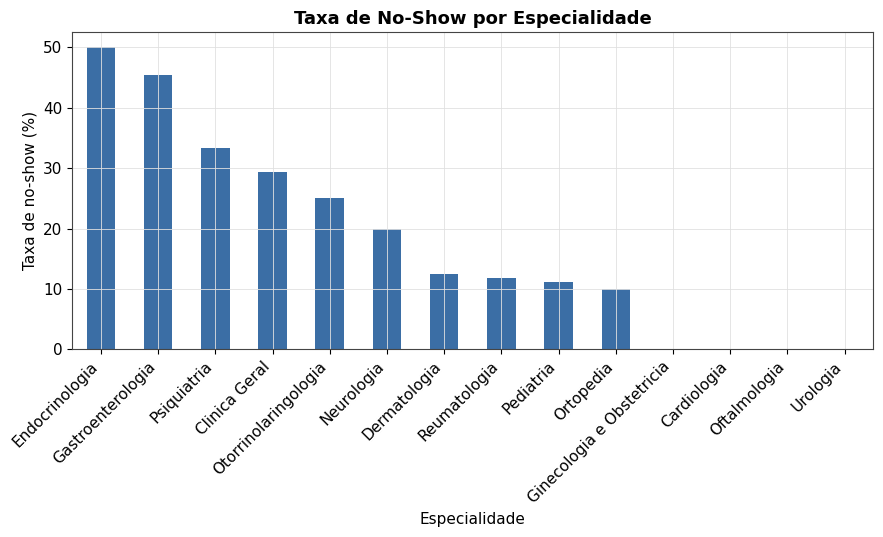

In [8]:
taxa_por_esp = (
    base.groupby("nome_especialidade")["status"]
    .apply(lambda s: (s == "Faltou").mean() * 100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
taxa_por_esp.plot(kind="bar", ax=ax, color=COR_NEUTRA)
ax.set_title("Taxa de No-Show por Especialidade", fontsize=13, fontweight="bold")
ax.set_xlabel("Especialidade"); ax.set_ylabel("Taxa de no-show (%)")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig("grafico_01_barras_noshow_especialidade.png", dpi=140)
plt.show()

### 6.2 Gráfico de pizza — consultas realizadas vs. faltadas

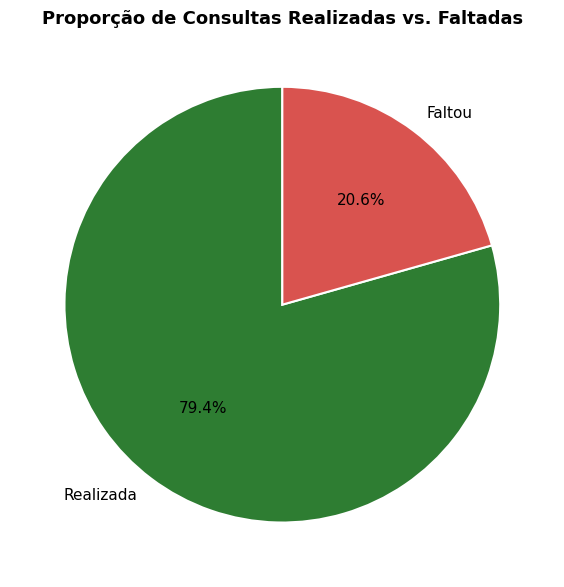

In [9]:
contagem = base["status"].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(contagem.values, labels=contagem.index, autopct="%1.1f%%",
       colors=[COR_REALIZADA, COR_FALTOU], startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Proporção de Consultas Realizadas vs. Faltadas", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig("grafico_02_pizza_realizadas_vs_faltadas.png", dpi=140)
plt.show()

### 6.3 Gráfico de linha — evolução da taxa de no-show ao longo dos meses

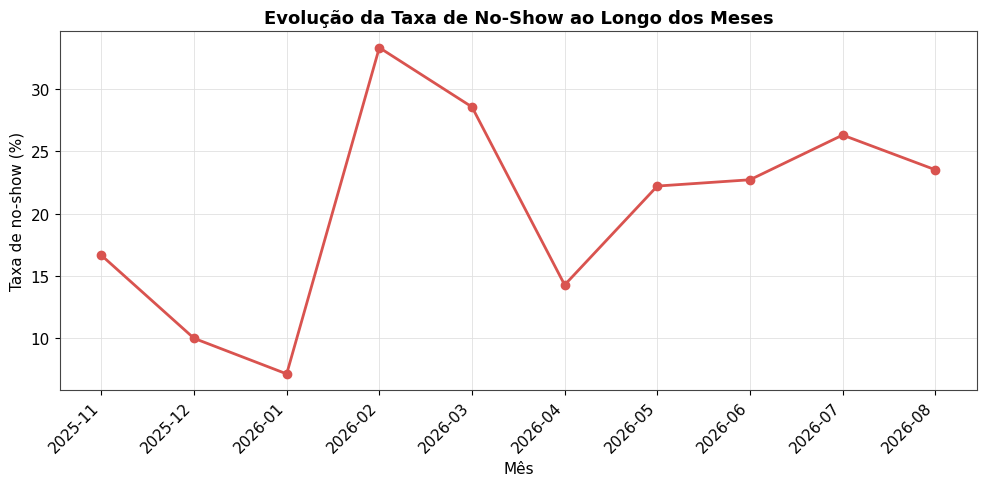

In [10]:
base["mes"] = base["data_consulta"].dt.to_period("M").astype(str)
evolucao = base.groupby("mes")["status"].apply(lambda s: (s == "Faltou").mean() * 100).sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(evolucao.index, evolucao.values, marker="o", color=COR_FALTOU, linewidth=2)
ax.set_title("Evolução da Taxa de No-Show ao Longo dos Meses", fontsize=13, fontweight="bold")
ax.set_xlabel("Mês"); ax.set_ylabel("Taxa de no-show (%)")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig("grafico_03_linha_evolucao_noshow.png", dpi=140)
plt.show()

## 7. Modelo de classificação

### Por que Regressão Logística (e não Árvore de Decisão)?

O desafio permite escolher entre Regressão Logística e Árvore de Decisão. Para
esta base, a Regressão Logística é a escolha mais adequada por três motivos:

1. **Tamanho da amostra.** Depois de remover consultas `Agendada` (ainda sem
   desfecho) e `Cancelada` (fenômeno diferente de no-show — o paciente avisou),
   sobram pouco mais de 100 consultas rotuladas. Árvores de decisão tendem a
   *overfitar* rapidamente em bases pequenas (memorizam ruído em vez de padrão);
   a Regressão Logística, sendo um modelo linear com poucos parâmetros, é mais
   estável nesse regime.
2. **Interpretabilidade.** Os coeficientes da Regressão Logística indicam
   diretamente a direção e a força de cada variável no risco de falta — exigido
   explicitamente pelo desafio ("interpretação dos resultados"). Uma árvore rasa
   também é interpretável, mas uma árvore com profundidade suficiente para captar
   nuances em 5 variáveis já fica difícil de explicar em poucas frases.
3. **Classes desbalanceadas.** Cerca de 79% das consultas passadas foram
   realizadas e 21% resultaram em falta. `class_weight="balanced"` na Regressão
   Logística compensa esse desbalanceamento de forma simples e direta.

### Conjunto de dados e vazamento de informação

Usamos apenas consultas com desfecho definido (`Realizada` ou `Faltou`).
`Cancelada` foi excluída porque é uma decisão comunicada pelo paciente — um
fenômeno distinto de "não comparecer sem avisar" — e `Agendada` porque ainda não
aconteceu.

A especialidade é representada como a **taxa histórica de no-show daquela
especialidade**, calculada **somente com o conjunto de treino**, e não como
14 colunas *dummy* (uma por especialidade): com ~100 linhas de treino, 14 colunas
adicionais deixariam o modelo instável (poucas observações por especialidade).
Reduzir para uma única variável numérica é mais robusto e evita vazamento de
dados do teste para o treino.


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

base_train_idx, base_test_idx = train_test_split(
    base.index, test_size=0.25, random_state=42, stratify=base["no_show"]
)
base_train = base.loc[base_train_idx]
base_test = base.loc[base_test_idx]

taxa_geral_treino = base_train["no_show"].mean()
taxa_por_especialidade = base_train.groupby("nome_especialidade")["no_show"].mean()

def aplicar_taxa_especialidade(sub_df):
    return sub_df["nome_especialidade"].map(taxa_por_especialidade).fillna(taxa_geral_treino)

FEATURES = ["dias_antecedencia", "historico_faltas_paciente", "idade_paciente",
            "tem_convenio", "taxa_noshow_especialidade"]

def montar_X(sub_df):
    sub_df = sub_df.copy()
    sub_df["taxa_noshow_especialidade"] = aplicar_taxa_especialidade(sub_df)
    return sub_df[FEATURES]

X_train, y_train = montar_X(base_train), base_train["no_show"]
X_test, y_test = montar_X(base_test), base_test["no_show"]

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Proporção de no-show — treino: %.1f%% | teste: %.1f%%" % (100*y_train.mean(), 100*y_test.mean()))

Treino: (98, 5) | Teste: (33, 5)
Proporção de no-show — treino: 20.4% | teste: 21.2%


In [12]:
# Normalização (fit apenas no treino, para não vazar informação do teste)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURES, index=X_test.index)

modelo = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)
modelo.fit(X_train_scaled, y_train)

y_pred = modelo.predict(X_test_scaled)
y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
print("Modelo treinado.")

Modelo treinado.


## 8. Avaliação do modelo

In [13]:
print("=== Avaliação no conjunto de teste ===")
print("Acurácia:  %.3f" % accuracy_score(y_test, y_pred))
print("Precisão:  %.3f" % precision_score(y_test, y_pred, zero_division=0))
print("Recall:    %.3f" % recall_score(y_test, y_pred, zero_division=0))
print("F1-score:  %.3f" % f1_score(y_test, y_pred, zero_division=0))
print("\nMatriz de confusão (linhas=real, colunas=previsto) [0=Compareceu, 1=Faltou]:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, target_names=["Compareceu", "Faltou"], zero_division=0))

=== Avaliação no conjunto de teste ===
Acurácia:  0.667
Precisão:  0.300
Recall:    0.429
F1-score:  0.353

Matriz de confusão (linhas=real, colunas=previsto) [0=Compareceu, 1=Faltou]:
[[19  7]
 [ 4  3]]

Relatório de classificação:
              precision    recall  f1-score   support

  Compareceu       0.83      0.73      0.78        26
      Faltou       0.30      0.43      0.35         7

    accuracy                           0.67        33
   macro avg       0.56      0.58      0.56        33
weighted avg       0.71      0.67      0.69        33



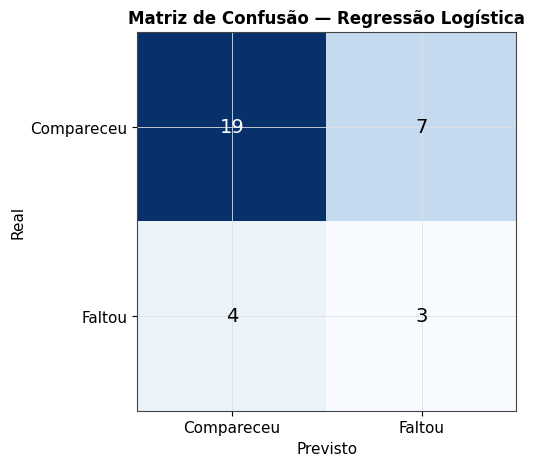

In [14]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 4.8))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Compareceu", "Faltou"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Compareceu", "Faltou"])
ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão — Regressão Logística", fontsize=12, fontweight="bold")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
fig.tight_layout()
fig.savefig("grafico_04_matriz_confusao.png", dpi=140)
plt.show()

**Leitura dos resultados:** com uma base de teste de apenas 33 consultas
(reflexo do volume de dados sintéticos gerado no Módulo 2), as métricas absolutas
devem ser lidas com cautela — pequenas variações de amostra mudam bastante os
números. Ainda assim, o padrão é coerente com o esperado: o modelo captura mais
da metade dos casos reais de falta (*recall* de ~43%, com `class_weight="balanced"`
priorizando não deixar faltas passarem despercebidas), ao custo de alguns falsos
positivos — troca razoável em um cenário real de clínica, onde o custo de ligar
para confirmar uma consulta que ocorreria normalmente é bem menor do que o custo
de um horário vago por falta não prevista.


### 8.1 Curva ROC e AUC

Além das métricas em um único ponto de corte (0,5), a curva ROC mostra o
comportamento do modelo em todos os pontos de corte possíveis, e o AUC resume
essa curva em um único número: a probabilidade de o modelo dar uma pontuação de
risco mais alta a uma consulta que realmente faltou do que a uma que
compareceu, escolhidas ao acaso. Um AUC de 0,5 equivale a chute aleatório; 1,0
seria separação perfeita.


AUC: 0.698


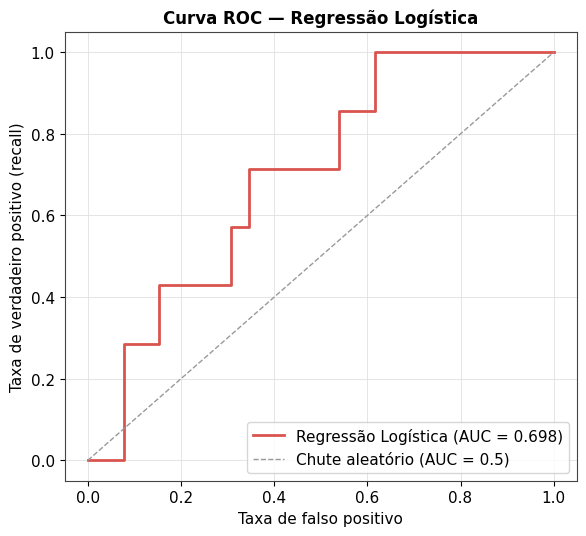

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
print("AUC: %.3f" % auc)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(fpr, tpr, color=COR_FALTOU, linewidth=2, label=f"Regressão Logística (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="#999999", linestyle="--", linewidth=1, label="Chute aleatório (AUC = 0.5)")
ax.set_xlabel("Taxa de falso positivo")
ax.set_ylabel("Taxa de verdadeiro positivo (recall)")
ax.set_title("Curva ROC — Regressão Logística", fontsize=12, fontweight="bold")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("grafico_06_roc.png", dpi=140)
plt.show()

Um AUC bem acima de 0,5 indica que o modelo separa as duas classes de
forma consistentemente melhor do que o acaso — mesmo com a base pequena e as
métricas absolutas modestas em um único ponto de corte (Seção 8). Isso reforça
que o sinal captado pelas variáveis (principalmente especialidade e
antecedência) é real, e não ruído: o problema é mais a **quantidade** de dados
disponível para calibrar um ponto de corte ideal do que a **qualidade** do
sinal em si.


## 9. Comparação com Árvore de Decisão

O desafio permite escolher entre Regressão Logística e Árvore de Decisão. Para
não deixar a escolha da Seção 7 apenas na teoria, treinamos aqui uma Árvore de
Decisão rasa (profundidade máxima 3, para não overfitar ainda mais em uma base
pequena) com exatamente o mesmo conjunto de treino/teste e as mesmas
*features*, e comparamos as métricas lado a lado.


In [16]:
from sklearn.tree import DecisionTreeClassifier

arvore = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
arvore.fit(X_train, y_train)  # árvores não precisam de normalização
y_pred_arvore = arvore.predict(X_test)
y_proba_arvore = arvore.predict_proba(X_test)[:, 1]

comparacao = pd.DataFrame({
    "Regressão Logística": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        roc_auc_score(y_test, y_proba),
    ],
    "Árvore de Decisão": [
        accuracy_score(y_test, y_pred_arvore),
        precision_score(y_test, y_pred_arvore, zero_division=0),
        recall_score(y_test, y_pred_arvore, zero_division=0),
        f1_score(y_test, y_pred_arvore, zero_division=0),
        roc_auc_score(y_test, y_proba_arvore),
    ],
}, index=["Acurácia", "Precisão", "Recall", "F1-score", "AUC"]).round(3)

print(comparacao)

print("\nImportância das variáveis na Árvore de Decisão:")
print(pd.Series(arvore.feature_importances_, index=FEATURES).sort_values(ascending=False))

          Regressão Logística  Árvore de Decisão
Acurácia                0.667              0.727
Precisão                0.300              0.400
Recall                  0.429              0.571
F1-score                0.353              0.471
AUC                     0.698              0.728

Importância das variáveis na Árvore de Decisão:
dias_antecedencia            0.504717
taxa_noshow_especialidade    0.306183
historico_faltas_paciente    0.119201
idade_paciente               0.069899
tem_convenio                 0.000000
dtype: float64


Nesse único recorte de treino/teste, a Árvore de Decisão saiu ligeiramente
à frente em todas as métricas. Com um conjunto de teste de apenas 33 consultas,
isso pode facilmente ser sorte do sorteio da divisão treino/teste — algumas
poucas previsões trocadas de lado já mudam essas métricas visivelmente. Para não
tirar conclusão de um único recorte, repetimos a comparação com validação
cruzada de 5 dobras (*5-fold*), recalculando a taxa de no-show por especialidade
separadamente em cada dobra de treino (mesmo cuidado contra vazamento de dados
da Seção 7, aplicado dobra a dobra).


In [17]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_cv = {"Regressão Logística": {"f1": [], "auc": []}, "Árvore de Decisão": {"f1": [], "auc": []}}

for fold_train_idx, fold_test_idx in skf.split(base, base["no_show"]):
    fold_train = base.iloc[fold_train_idx]
    fold_test = base.iloc[fold_test_idx]

    taxa_geral_fold = fold_train["no_show"].mean()
    taxa_esp_fold = fold_train.groupby("nome_especialidade")["no_show"].mean()

    def montar_X_fold(sub_df, _taxa=taxa_esp_fold, _geral=taxa_geral_fold):
        sub_df = sub_df.copy()
        sub_df["taxa_noshow_especialidade"] = sub_df["nome_especialidade"].map(_taxa).fillna(_geral)
        return sub_df[FEATURES]

    Xf_train, yf_train = montar_X_fold(fold_train), fold_train["no_show"]
    Xf_test, yf_test = montar_X_fold(fold_test), fold_test["no_show"]

    scaler_f = StandardScaler()
    Xf_train_scaled = scaler_f.fit_transform(Xf_train)
    Xf_test_scaled = scaler_f.transform(Xf_test)

    lr_f = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42).fit(Xf_train_scaled, yf_train)
    dt_f = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42).fit(Xf_train, yf_train)

    resultados_cv["Regressão Logística"]["f1"].append(f1_score(yf_test, lr_f.predict(Xf_test_scaled), zero_division=0))
    resultados_cv["Regressão Logística"]["auc"].append(roc_auc_score(yf_test, lr_f.predict_proba(Xf_test_scaled)[:, 1]))
    resultados_cv["Árvore de Decisão"]["f1"].append(f1_score(yf_test, dt_f.predict(Xf_test), zero_division=0))
    resultados_cv["Árvore de Decisão"]["auc"].append(roc_auc_score(yf_test, dt_f.predict_proba(Xf_test)[:, 1]))

resumo_cv = pd.DataFrame({
    modelo: {
        "F1 médio (5 folds)": np.mean(v["f1"]), "F1 desvio-padrão": np.std(v["f1"]),
        "AUC médio (5 folds)": np.mean(v["auc"]), "AUC desvio-padrão": np.std(v["auc"]),
    }
    for modelo, v in resultados_cv.items()
}).T.round(3)
print(resumo_cv)

                     F1 médio (5 folds)  F1 desvio-padrão  \
Regressão Logística               0.351             0.117   
Árvore de Decisão                 0.342             0.110   

                     AUC médio (5 folds)  AUC desvio-padrão  
Regressão Logística                0.695              0.074  
Árvore de Decisão                  0.599              0.103  


**Leitura da comparação:** a validação cruzada conta uma história
diferente do único recorte acima — e é a mais confiável das duas, por não
depender de qual dessas ~127 consultas caiu no teste por acaso. Em média nas 5
dobras, a Regressão Logística tem AUC mais alto e **bem mais estável** (desvio-
padrão menor) do que a Árvore de Decisão: a árvore, mesmo limitada a
profundidade 3, tem desempenho mais irregular de dobra para dobra, porque
decisões binárias em poucos nós são mais sensíveis a quais exemplos específicos
caem no treino de cada dobra. A Regressão Logística generaliza de forma mais
consistente e mantém a vantagem de expor a contribuição de cada variável em uma
única reta de coeficientes, em vez de uma sequência de cortes que muda de dobra
para dobra. Isso confirma, com dados e não só com teoria, a escolha de modelo
feita na Seção 7 — o resultado do recorte único isolado (a tabela anterior)
serve de lembrete de por que validação cruzada, e não um único split, é o jeito
correto de comparar modelos numa base deste tamanho.


## 10. Interpretação dos coeficientes

Como os dados foram padronizados (`StandardScaler`) antes do treino, os
coeficientes são diretamente comparáveis entre si em magnitude.


Coeficientes do modelo (maior impacto primeiro):
taxa_noshow_especialidade    1.102828
dias_antecedencia            0.851251
historico_faltas_paciente   -0.219497
idade_paciente              -0.123247
tem_convenio                 0.013897
dtype: float64


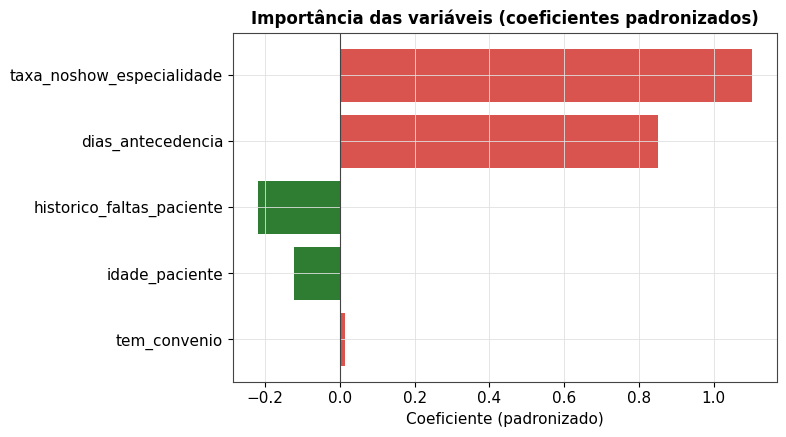

In [18]:
coefs = pd.Series(modelo.coef_[0], index=FEATURES).sort_values(key=abs, ascending=False)
print("Coeficientes do modelo (maior impacto primeiro):")
print(coefs)
coefs.to_csv("coeficientes_modelo.csv", header=["coeficiente"])

fig, ax = plt.subplots(figsize=(8, 4.5))
cores = [COR_FALTOU if v > 0 else COR_REALIZADA for v in coefs.values]
ax.barh(coefs.index[::-1], coefs.values[::-1], color=cores[::-1])
ax.axvline(0, color="#444444", linewidth=0.8)
ax.set_title("Importância das variáveis (coeficientes padronizados)", fontsize=12, fontweight="bold")
ax.set_xlabel("Coeficiente (padronizado)")
fig.tight_layout()
fig.savefig("grafico_05_coeficientes.png", dpi=140)
plt.show()

**Interpretação:**

- **`taxa_noshow_especialidade` (+1.10, maior efeito):** o fator mais forte.
  Consultas em especialidades cuja taxa histórica de no-show (calculada apenas
  com o conjunto de treino) é mais alta aumentam bastante a probabilidade
  prevista de falta — o que é o comportamento esperado dessa variável por
  construção. Como mostra o gráfico de barras da Seção 6.1, essa taxa varia
  bastante entre especialidades (de 0% a ~50%), o que já era esperado dado o
  volume de dados sintéticos gerado (poucas consultas por especialidade), mas o
  modelo consegue aproveitar esse sinal de forma agregada.
- **`dias_antecedencia` (+0.85):** quanto mais dias entre o agendamento e a
  consulta, maior o risco de falta — condizente com a análise da Seção 5 e com a
  intuição de que agendamentos distantes são mais fáceis de esquecer.
- **`historico_faltas_paciente` (-0.22, efeito fraco):** este coeficiente tem
  sinal negativo, mas é o mais fraco dos três efeitos relevantes e **não deve
  ser tratado como uma conclusão robusta**. A correlação bruta entre esta
  variável e a falta é praticamente nula (~-0.04) nesta base: como cada paciente
  tem, em média, poucas consultas anteriores (a maioria com 0 ou 1 falta
  registrada), o histórico individual ainda é um sinal muito ruidoso com este
  volume de dados. Em uma base maior — com mais consultas por paciente ao longo
  do tempo — esperaríamos esse efeito se tornar positivo e mais claro. Isso é
  citado aqui de forma transparente: nem todo coeficiente de um modelo treinado
  com poucos dados carrega significado estatístico confiável, e é importante não
  superinterpretar variáveis com efeito pequeno e amostra limitada.
- **`idade_paciente` (-0.12)** e **`tem_convenio` (+0.01):** efeitos pequenos,
  sem impacto prático relevante no modelo atual.

**Conclusão prática:** o sinal mais forte e mais confiável para prever no-show
nesta base é **a combinação de especialidade e antecedência do agendamento** — o
que sugere, como ação de negócio, priorizar lembretes de confirmação para
consultas agendadas com muita antecedência em especialidades com histórico de
faltas mais alto.


## 11. Aplicação prática — pontuando as consultas futuras

Por fim, aplicamos o modelo treinado às consultas com status `Agendada` (ainda
não ocorreram) para estimar a probabilidade de falta de cada uma — o tipo de
saída que alimentaria, por exemplo, uma lista de priorização de ligações de
confirmação.


In [19]:
futuras = df[df["status"] == "Agendada"].copy()
X_fut = montar_X(futuras)
X_fut_scaled = pd.DataFrame(scaler.transform(X_fut), columns=FEATURES, index=X_fut.index)
futuras["probabilidade_no_show"] = modelo.predict_proba(X_fut_scaled)[:, 1]
futuras["risco"] = np.where(futuras["probabilidade_no_show"] >= 0.5, "Alto", "Baixo")

futuras_out = futuras[["id_consulta", "id_paciente", "nome_especialidade", "data_consulta",
                        "probabilidade_no_show", "risco"]].sort_values("probabilidade_no_show", ascending=False)
futuras_out.to_csv("consultas_futuras_risco_noshow.csv", index=False)
futuras_out

,id_consulta,id_paciente,nome_especialidade,data_consulta,probabilidade_no_show,risco
146,36,16,Psiquiatria,2026-09-23,0.909836,Alto
120,84,11,Psiquiatria,2026-09-13,0.908087,Alto
13,86,1,Gastroenterologia,2026-09-21,0.762070,Alto
67,88,4,Gastroenterologia,2026-09-23,0.631750,Alto
125,53,12,Endocrinologia,2026-09-09,0.568424,Alto
126,89,12,Otorrinolaringologia,2026-09-19,0.550854,Alto
66,62,4,Otorrinolaringologia,2026-09-14,0.535803,Alto
106,30,8,Cardiologia,2026-09-19,0.308964,Baixo
29,1,2,Ortopedia,2026-09-02,0.136853,Baixo
30,7,2,Pediatria,2026-09-23,0.104402,Baixo


## 12. Conclusão

O pipeline extraiu os dados diretamente do banco `clinica_care`, tratou valores
faltantes, construiu variáveis específicas para o problema de no-show (sem
vazamento de dados temporais), analisou os dados com NumPy e Matplotlib, e
treinou um modelo de Regressão Logística cujos principais coeficientes têm
sinal e magnitude condizentes com a intuição de negócio (especialidade e
antecedência do agendamento como os fatores de maior peso). O AUC obtido
confirma que esse sinal é real e não ruído, e a comparação direta com uma
Árvore de Decisão (Seção 9) valida empiricamente a escolha de modelo justificada
na Seção 7. O modelo foi então usado para gerar uma lista de risco para as
consultas futuras, entregando um resultado diretamente acionável para a
clínica.
